**OLA RIDE INSIGHTS - Data Science Project**

**1. Data Upload and Exploration**


***Import Libraries***

In [178]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

***Reading Data From Ola_Dataset***

In [206]:
url = "/content/drive/MyDrive/OLA_DataSet.xlsx"

df = pd.read_excel(url) # reading file

df.head() #Exploring Data

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images
0,2024-07-26 14:00:00,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,NaN,Personal & Car related issue,NaN,NaN,444,NaN,0,NaN,NaN,https://cdn-icons-png.flaticon.com/128/14183/1...
1,2024-07-25 22:20:00,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,NaN,NaN,No,NaN,158,Cash,13,4.1,4.0,https://cdn-icons-png.flaticon.com/128/9983/99...
2,2024-07-30 19:59:00,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,NaN,NaN,No,NaN,386,UPI,40,4.2,4.8,https://cdn-icons-png.flaticon.com/128/9983/99...
3,2024-07-22 03:15:00,03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,Driver is not moving towards pickup location,NaN,NaN,NaN,384,NaN,0,NaN,NaN,https://cdn-icons-png.flaticon.com/128/6839/68...
4,2024-07-02 09:02:00,09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,NaN,NaN,No,NaN,822,Credit Card,45,4.0,3.0,https://cdn-icons-png.flaticon.com/128/3202/32...


***Checking Data Types and Null Values***

In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Date                        103024 non-null  datetime64[ns]
 1   Time                        103024 non-null  object        
 2   Booking_ID                  103024 non-null  object        
 3   Booking_Status              103024 non-null  object        
 4   Customer_ID                 103024 non-null  object        
 5   Vehicle_Type                103024 non-null  object        
 6   Pickup_Location             103024 non-null  object        
 7   Drop_Location               103024 non-null  object        
 8   V_TAT                       63967 non-null   float64       
 9   C_TAT                       63967 non-null   float64       
 10  Canceled_Rides_by_Customer  10499 non-null   object        
 11  Canceled_Rides_by_Driver    18434 non-n

***Checking Number of Rows And Columns***

In [208]:
df.shape

(103024, 20)

***Checking Summary Information***

In [209]:
df.describe().round()

,Date,V_TAT,C_TAT,Booking_Value,Ride_Distance,Driver_Ratings,Customer_Rating
count,103024,63967.0,63967.0,103024.0,103024.0,63967.0,63967.0
mean,2024-07-16 11:31:38.879678720,171.0,85.0,549.0,14.0,4.0,4.0
min,2024-07-01 00:00:00,35.0,25.0,100.0,0.0,3.0,3.0
25%,2024-07-08 18:41:00,98.0,55.0,242.0,0.0,4.0,4.0
50%,2024-07-16 11:23:00,168.0,85.0,386.0,8.0,4.0,4.0
75%,2024-07-24 05:18:00,238.0,115.0,621.0,26.0,4.0,4.0
max,2024-07-31 23:58:00,308.0,145.0,2999.0,49.0,5.0,5.0
std,NaN,81.0,36.0,537.0,16.0,1.0,1.0


***Checking Null Values***

In [210]:
df.isnull().sum()

,0
Date,0
Time,0
Booking_ID,0
Booking_Status,0
Customer_ID,0
Vehicle_Type,0
Pickup_Location,0
Drop_Location,0
V_TAT,39057
C_TAT,39057


***Checking null value percentage***

In [211]:
100* df.isnull().sum()/df.shape[0]

,0
Date,0.000000
Time,0.000000
Booking_ID,0.000000
Booking_Status,0.000000
Customer_ID,0.000000
Vehicle_Type,0.000000
Pickup_Location,0.000000
Drop_Location,0.000000
V_TAT,37.910584
C_TAT,37.910584


***Checking Duplicate Values***

In [212]:
df[df.duplicated()].shape

(0, 20)

***Checking Duplicate Values in primary key***

In [213]:
df['Booking_ID'].value_counts()

,count
Booking_ID,
CNR3204013257,1
CNR5979995999,1
CNR3766293727,1
CNR1573041532,1
CNR2619112624,1
...,...
CNR1797421769,1
CNR2395710036,1
CNR2982357879,1


***Checking Categorial Columns for Unique Values***

In [214]:
for col in df.columns:
  if df[col].nunique()<20 :
    print(df[col].value_counts())
    print("-"*50)


Booking_Status
Success                 63967
Canceled by Driver      18434
Canceled by Customer    10499
Driver Not Found        10124
Name: count, dtype: int64
--------------------------------------------------
Vehicle_Type
Prime Sedan    14877
eBike          14816
Auto           14755
Prime Plus     14707
Bike           14662
Prime SUV      14655
Mini           14552
Name: count, dtype: int64
--------------------------------------------------
Canceled_Rides_by_Customer
Driver is not moving towards pickup location    3175
Driver asked to cancel                          2670
Change of plans                                 2081
AC is Not working                               1568
Wrong Address                                   1005
Name: count, dtype: int64
--------------------------------------------------
Canceled_Rides_by_Driver
Personal & Car related issue           6542
Customer related issue                 5413
Customer was coughing/sick             3654
More than permitted peopl

__DATA CLEANING__

***Handling Missing Values***

In [215]:
df['Driver_Ratings'].fillna(df['Driver_Ratings'].median(),inplace=True)       # Replace nulls in column 'Driver_Rating' with 0
df['Customer_Rating'].fillna(df['Customer_Rating'].median(),inplace=True)     # Replace nulls in column 'Customer_Rating' with 0

df['Payment_Method'] = df['Payment_Method'].fillna('NotAvailable')                          # Replace nulls in column 'Payment_Method' with 'NA'
df['Canceled_Rides_by_Customer'] = df['Canceled_Rides_by_Customer'].fillna('NotAvailable')  # Replace nulls in column 'Canceled_Rides_by_Customer' with 'NA'
df['Canceled_Rides_by_Driver'] = df['Canceled_Rides_by_Driver'].fillna('NotAvailable')      # Replace nulls in column 'Canceled_Rides_by_Driver' with 'NA'
df['Incomplete_Rides'] = df['Incomplete_Rides'].fillna('NotAvailable')                      # Replace nulls in column 'Incomplete_Rides' with 'NA'
df['Incomplete_Rides_Reason'] = df['Incomplete_Rides_Reason'].fillna('NotAvailable')        # Replace nulls in column 'Incomplete_Rides_Reason' with 'NA'


df['V_TAT'] = df['V_TAT'].fillna(df.groupby('Vehicle_Type')['V_TAT'].transform('median'))       # Replace nulls in column 'V_TAT' with median group by Vehicle_Type
df['C_TAT'] = df['C_TAT'].fillna(df.groupby('Vehicle_Type')['C_TAT'].transform('median'))       # Replace nulls in column 'C_TAT' with median group by Vehicle_Type
df['V_TAT'] = df['V_TAT'].fillna(0)                     # Replace nulls in column 'V_TAT' with 0 as group not available
df['C_TAT'] = df['C_TAT'].fillna(0)                     # Replace nulls in column 'V_TAT' with 0 as group not available

***Checking Null Values***

In [216]:
100* df.isnull().sum()/df.shape[0]

,0
Date,0.0
Time,0.0
Booking_ID,0.0
Booking_Status,0.0
Customer_ID,0.0
Vehicle_Type,0.0
Pickup_Location,0.0
Drop_Location,0.0
V_TAT,0.0
C_TAT,0.0


***Removing Irrelevant Columns***

In [217]:
df.drop(['Vehicle Images'],axis=1,inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 19 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Date                        103024 non-null  datetime64[ns]
 1   Time                        103024 non-null  object        
 2   Booking_ID                  103024 non-null  object        
 3   Booking_Status              103024 non-null  object        
 4   Customer_ID                 103024 non-null  object        
 5   Vehicle_Type                103024 non-null  object        
 6   Pickup_Location             103024 non-null  object        
 7   Drop_Location               103024 non-null  object        
 8   V_TAT                       103024 non-null  float64       
 9   C_TAT                       103024 non-null  float64       
 10  Canceled_Rides_by_Customer  103024 non-null  object        
 11  Canceled_Rides_by_Driver    103024 non-

In [218]:
df.head()


,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating
0,2024-07-26 14:00:00,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,168.0,85.0,NotAvailable,Personal & Car related issue,NotAvailable,NotAvailable,444,NotAvailable,0,4.0,4.0
1,2024-07-25 22:20:00,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,NotAvailable,NotAvailable,No,NotAvailable,158,Cash,13,4.1,4.0
2,2024-07-30 19:59:00,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,NotAvailable,NotAvailable,No,NotAvailable,386,UPI,40,4.2,4.8
3,2024-07-22 03:15:00,03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,168.0,85.0,Driver is not moving towards pickup location,NotAvailable,NotAvailable,NotAvailable,384,NotAvailable,0,4.0,4.0
4,2024-07-02 09:02:00,09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,NotAvailable,NotAvailable,No,NotAvailable,822,Credit Card,45,4.0,3.0


***Outlier Treatment***

In [219]:
df.describe().round()

,Date,V_TAT,C_TAT,Booking_Value,Ride_Distance,Driver_Ratings,Customer_Rating
count,103024,103024.0,103024.0,103024.0,103024.0,103024.0,103024.0
mean,2024-07-16 11:31:38.879678720,171.0,85.0,549.0,14.0,4.0,4.0
min,2024-07-01 00:00:00,35.0,25.0,100.0,0.0,3.0,3.0
25%,2024-07-08 18:41:00,140.0,75.0,242.0,0.0,4.0,4.0
50%,2024-07-16 11:23:00,168.0,85.0,386.0,8.0,4.0,4.0
75%,2024-07-24 05:18:00,196.0,95.0,621.0,26.0,4.0,4.0
max,2024-07-31 23:58:00,308.0,145.0,2999.0,49.0,5.0,5.0
std,NaN,64.0,28.0,537.0,16.0,0.0,0.0


***Boxplot for All numeric Columns***

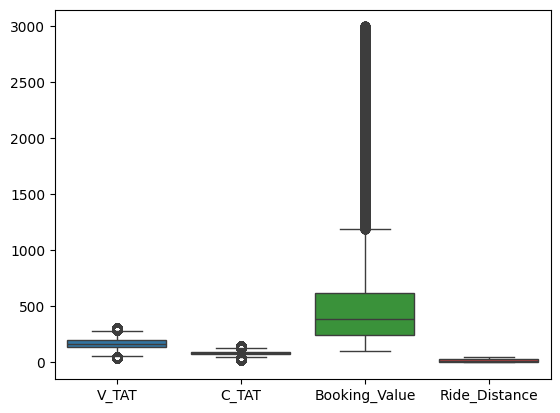

In [220]:
sns.boxplot(data=df[['V_TAT','C_TAT','Booking_Value','Ride_Distance']])
plt.show()

***Handling Outliers***

All these columns show outliers but since there are high number of outliers and removing it will result in huge data loss we are skipping it and handling other columns.*

In [221]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 19 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Date                        103024 non-null  datetime64[ns]
 1   Time                        103024 non-null  object        
 2   Booking_ID                  103024 non-null  object        
 3   Booking_Status              103024 non-null  object        
 4   Customer_ID                 103024 non-null  object        
 5   Vehicle_Type                103024 non-null  object        
 6   Pickup_Location             103024 non-null  object        
 7   Drop_Location               103024 non-null  object        
 8   V_TAT                       103024 non-null  float64       
 9   C_TAT                       103024 non-null  float64       
 10  Canceled_Rides_by_Customer  103024 non-null  object        
 11  Canceled_Rides_by_Driver    103024 non-

**Exporting Dataframe to CSV file**

In [222]:
df.to_csv('/content/drive/MyDrive/OLA_Cleaned.csv', index=False)